### About Dataset

#### Dataset Specifics: 

- Total records: `1,200+` **rows**

- Age range: `13`–`19` **years**

- Gender categories: `male`, `female` 

- Daily social media hours range: `1.0` – `8.0+` **hours** 

- Platforms tracked: `TikTok`, `Instagram`, `YouTube`, `Facebook`, `All Platforms` 

- Sleep hours range: `4.0` – `9.0` **hours** 

- Screen time before sleep range: `0.5` – `3.0` **hours**

- Academic performance score range: `2.00 – 4.00` **(likely GPA-equivalent) **

- Physical activity range: 0 – 2.0 hours per day (approx.)

- Social interaction levels: `low`, `medium`, `high` 

- Stress level range: `1 – 10` **(higher = more stress)**

- Anxiety level range: `1 – 10` **(higher = more anxiety)**

- Addiction level range: `1 – 10` **(higher = more addiction-like behavior)**

- Depression label: `0` (no) or `1` (yes) — mostly `0`, 

- imbalanced Mental health risk score range: `3 – 30` **(aggregate risk measure)**

- Sleep quality categories: `Poor`, `Fair`, `Good` 

- Digital wellbeing flag categories: `At Risk`, `Moderate`, `Healthy`

**Context This dataset is structured for exploratory analysis or predictive modeling in adolescent mental health research. Possible research questions include: Does higher daily social media use correlate with poorer sleep quality or higher anxiety? Which platforms are associated with greater mental health risk? Can mental health risk be predicted from digital behavior + lifestyle factors?**

**Notable patterns in the data:** mental_health_risk_scoreranges from 3 to 30. depression_label is mostly 0 (only a few rows show 1), indicating imbalanced classes. `digital_wellbeing_flag` = **"At Risk"** often appears with high social media hours, poor sleep, and high anxiety/stress scores.

**Sources & Origin Likely source type:** Synthetic data or anonymized survey data — possibly from a public health study, school-based wellness survey, or research simulation.

**Possible original contexts:** School mental health screening programs Digital wellness research (e.g., Common Sense Media, Pew Research–style surveys) Kaggle / UCI-style machine learning practice dataset Simulated data for teaching regression/classification in psychology or data science

**No real PII (Personally Identifiable Information)** is present — ages are integer, genders binary, no names/locations.

**Limitations & Cautions Synthetic nature likely — relationships may be engineered for teaching, not real-world causality. Depression label is rare — may limit classifier performance. Self-report bias is implied (stress, anxiety, addiction levels are subjective). No longitudinal data — snapshot correlations only.**

**Suggested Use Cases:** 

* Correlation/regression analysis *(predict mental_health_risk_score)*

* Binary classification (predict depression_label) 

* Clustering (find digital behavior profiles) Visualizing differences by gender, age, or platform

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

import warnings

warnings.filterwarnings('ignore')

In [2]:
# Load Datasset
data = pd.read_csv('Teen_Mental_Health.csv')

# Make a copy
df = data.copy(deep=True)

# First 5 rows
print('First Five rows:\n')
df.head(10)

First Five rows:



,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,male,7.9,Facebook,7.4,2.9,3.01,1.5,low,2,2,1,0,5,Fair,At Risk
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,19,Good,Moderate
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,8,Fair,Healthy
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0,17,Fair,Moderate
4,15,female,4.7,All Platforms,4.9,3.0,2.37,1.4,medium,3,5,2,0,10,Poor,Moderate
5,19,female,7.4,All Platforms,4.4,2.4,2.63,0.6,high,3,5,7,0,15,Poor,At Risk
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0,9,Fair,Moderate
7,16,male,4.0,All Platforms,4.2,0.5,2.40,1.3,low,6,10,5,0,21,Poor,Moderate
8,19,female,3.3,YouTube,5.0,2.1,2.04,0.9,high,1,10,9,0,20,Poor,Moderate
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0,6,Poor,Healthy


In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.shape

(1200, 16)

In [5]:
df.isna().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
mental_health_risk_score    0
sleep_quality               0
digital_wellbeing_flag      0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_quality      

In [7]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833,16.647500
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704,5.038128
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000,13.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000,17.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000,20.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000,30.000000


## EDA

97.42% samples are labeled as 0 (no depression) and 2.58% samples are labeled as 1 (depression).


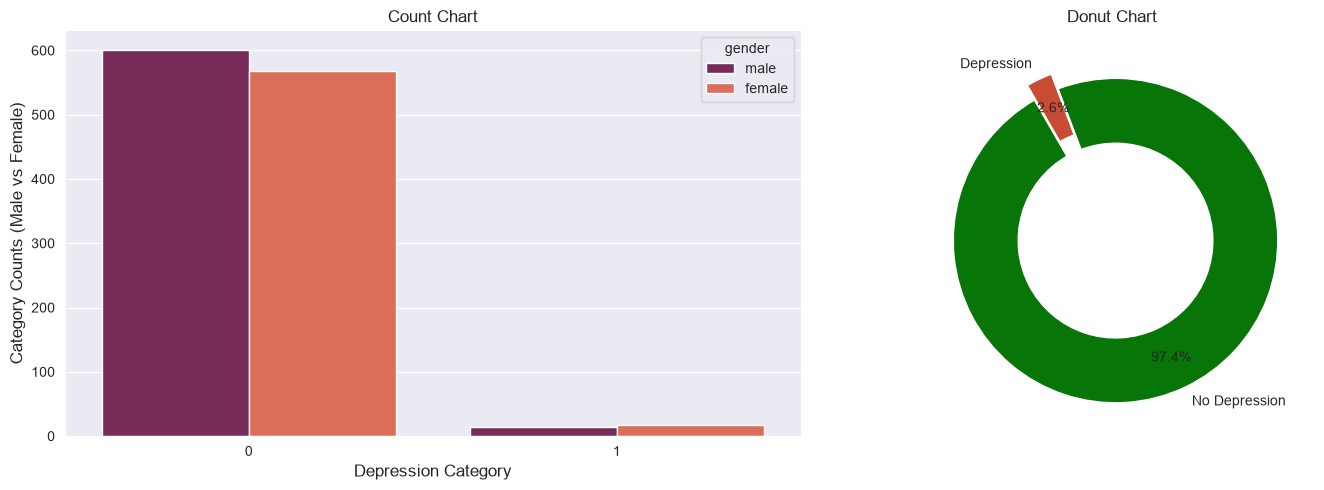

In [8]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

counts = df['depression_label'].value_counts()
label = ['No Depression', 'Depression']
explode = (0.05, 0.05)
colors = ["#077507", "#BE280AD5"]

# 1. Count plot for depression_label
sns.countplot(x='depression_label', data=df, order=counts.index, palette='rocket', hue='gender', ax=ax[0])
ax[0].set_title('Count Chart', fontsize=12)
ax[0].set_xlabel('Depression Category',fontsize=12)
ax[0].set_ylabel('Category Counts (Male vs Female)', fontsize=12)

# 2. Pie chart for depression_label
ax[1].pie(counts, 
            labels=label,
            colors=colors, 
            startangle=120,
            autopct='%1.1f%%', 
            pctdistance=0.80,
            explode=explode, 
            wedgeprops=dict(width=0.4, edgecolor='white'),)

ax[1].set_title('Donut Chart', fontsize=12)
plt.tight_layout()

print(f"{df['depression_label'].value_counts().values[0]/df.shape[0]*100:.2f}% samples are labeled as 0 (no depression) and {df['depression_label'].value_counts().values[1]/df.shape[0]*100:.2f}% samples are labeled as 1 (depression).")

Dataset is completely unbalanced, not even 10% belong to the class: 1 ('depression')

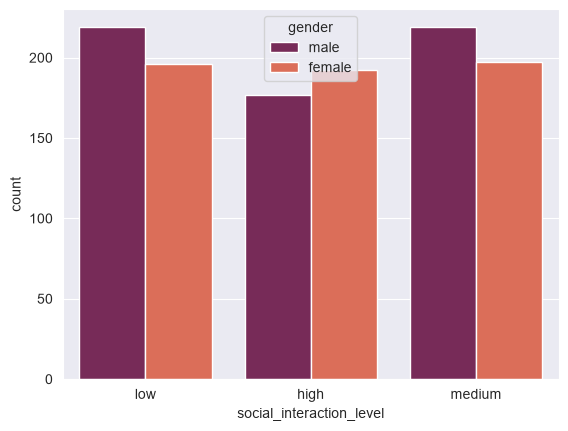

In [9]:
sns.countplot(x='social_interaction_level', data=df, hue='gender', palette='rocket');

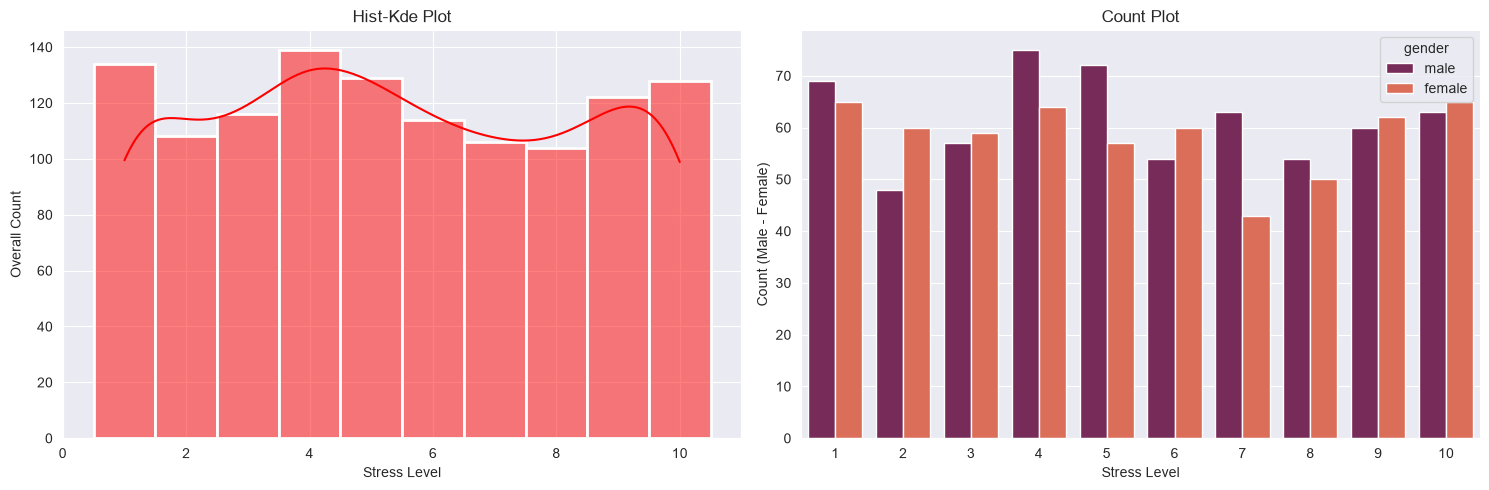

In [10]:
def plot_analyze(column: str, xLabel: str):
    fig, ax = plt.subplots(1,2, figsize=(15,5))
    sns.histplot(x=column,data=df, kde=True, discrete=True, linewidth=2, bins=10, ax=ax[0], color='red')
    sns.countplot(x=column,data=df, hue='gender', palette='rocket', ax=ax[1])
    ax[0].set_title('Hist-Kde Plot', fontsize=12)
    ax[0].set_xlabel(xLabel,fontsize=10)
    ax[0].set_ylabel('Overall Count',fontsize=10)

    ax[1].set_title('Count Plot', fontsize=12)
    ax[1].set_xlabel(xLabel, fontsize=10)
    ax[1].set_ylabel('Count (Male - Female)',fontsize=10)

    plt.tight_layout()
    plt.show()

plot_analyze('stress_level', xLabel='Stress Level')

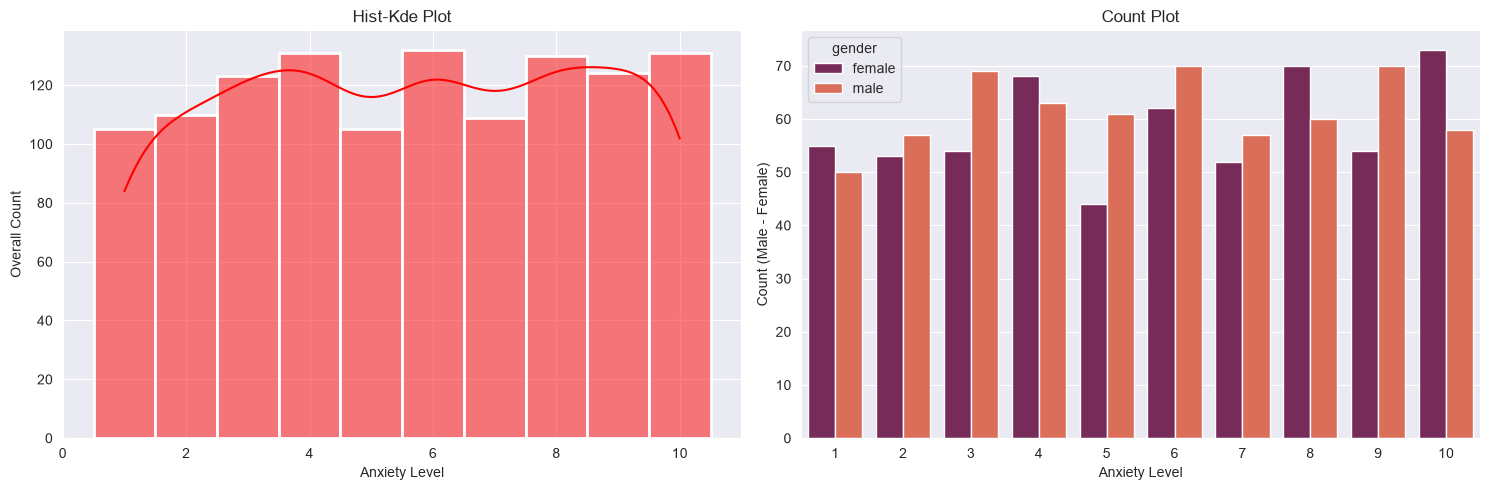

In [11]:
plot_analyze(column='anxiety_level', xLabel='Anxiety Level')

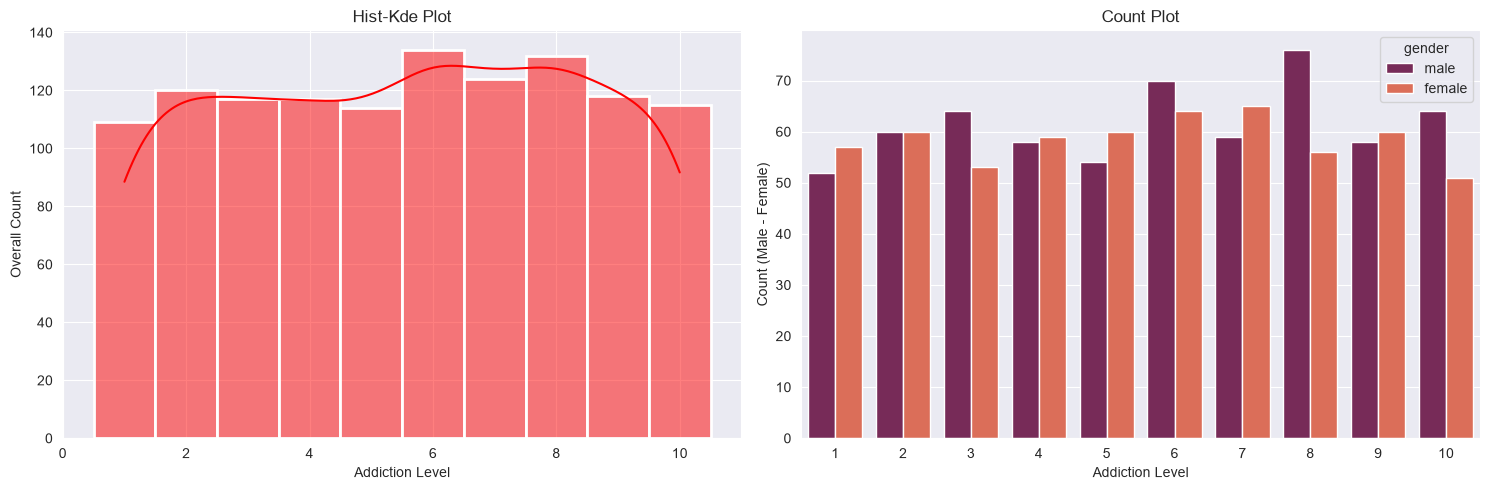

In [12]:
plot_analyze('addiction_level', xLabel='Addiction Level')

In [13]:
print(df['social_interaction_level'].value_counts().index)
print(df["stress_level"].value_counts().index.sort_values())
print(df['anxiety_level'].value_counts().index.sort_values())
print(df['addiction_level'].value_counts().index.sort_values())

Index(['medium', 'low', 'high'], dtype='str', name='social_interaction_level')
Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64', name='stress_level')
Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64', name='anxiety_level')
Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype='int64', name='addiction_level')


**The above three columns "stress_level", "anxiety_level" & "addiction_level" are marked between 1 to 10, we will convert these to 'high', 'medium' or 'low'.**

***Scale should be;***

`High`    --> *Above 7*

`Medium`  --> *Above 4 and Less than 7*

`Low`     --> *Less or Equals to 4*

Keeping the these levels as integer may effect the final models and can create confusion with increasing levels order

In [14]:
def categorize_level(val):
    if val <= 4:
        return 'low'
    elif 4 < val <= 7:
        return 'medium'
    else:
        return 'high'

In [15]:
# Categorizing the column
df["stress_level_category"] = df["stress_level"].apply(categorize_level)
df["anxiety_level_category"] = df["anxiety_level"].apply(categorize_level)
df["addiction_level_category"] = df["addiction_level"].apply(categorize_level)

In [16]:
# Dropping the columns not required
df = df.drop(['stress_level', 'anxiety_level', 'addiction_level'], axis=1)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   depression_label          1200 non-null   int64  
 10  mental_health_risk_score  1200 non-null   int64  
 11  sleep_quality             1200 non-null   str    
 12  digital_wellbeing_flag    1200 non-null   str    
 13  stress_level_category     1200 non-null   str    
 14  anxiety_level_categ

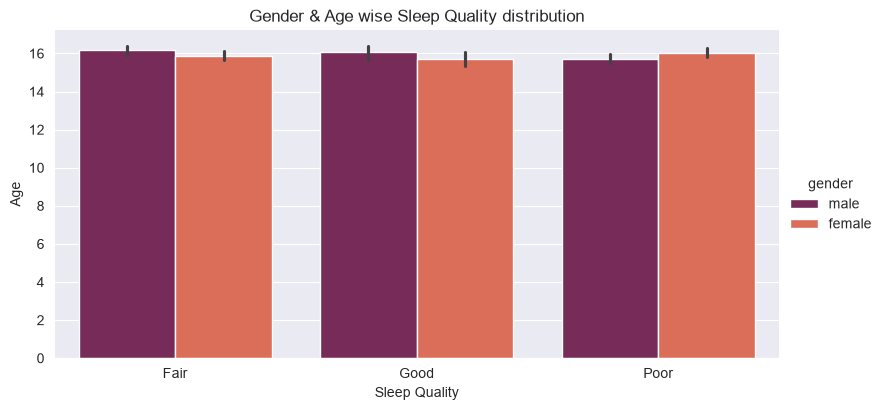

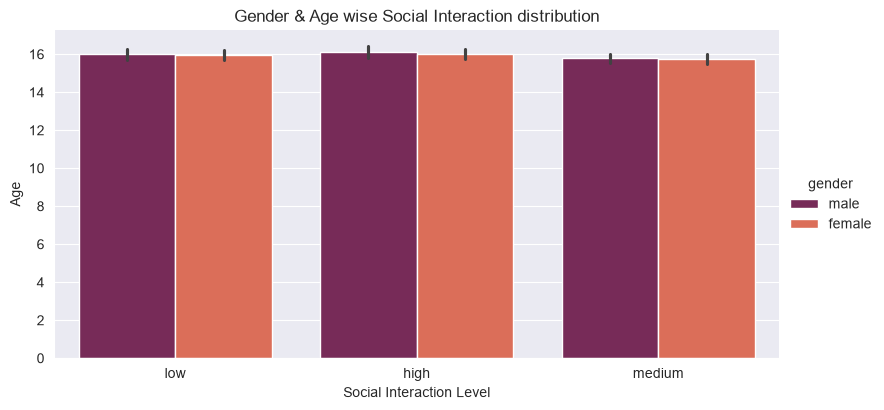

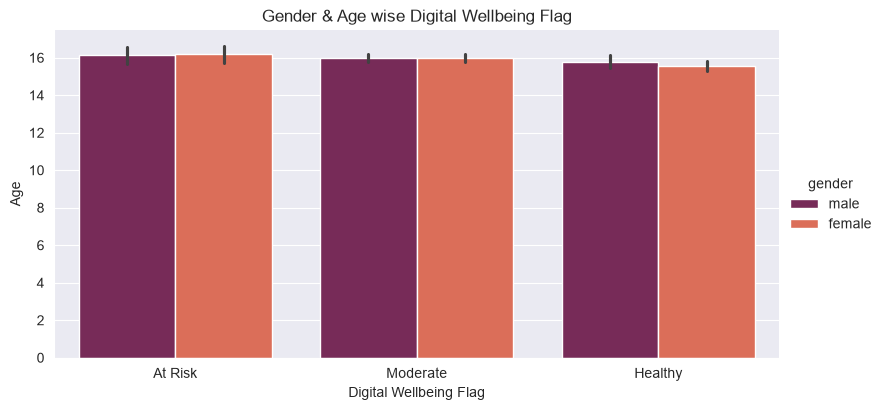

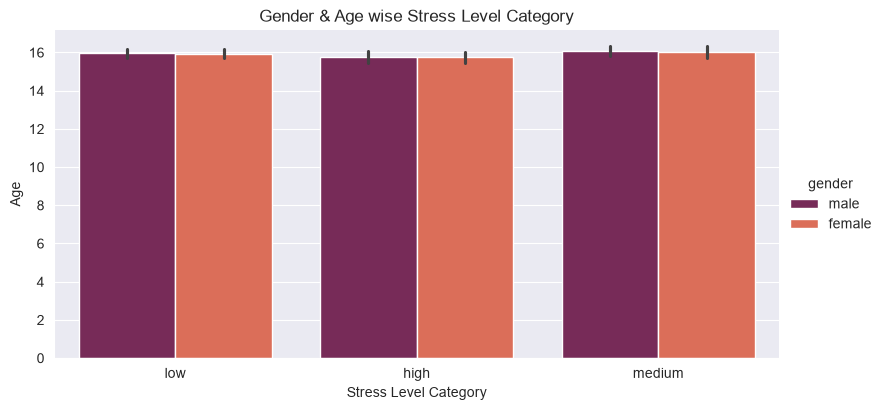

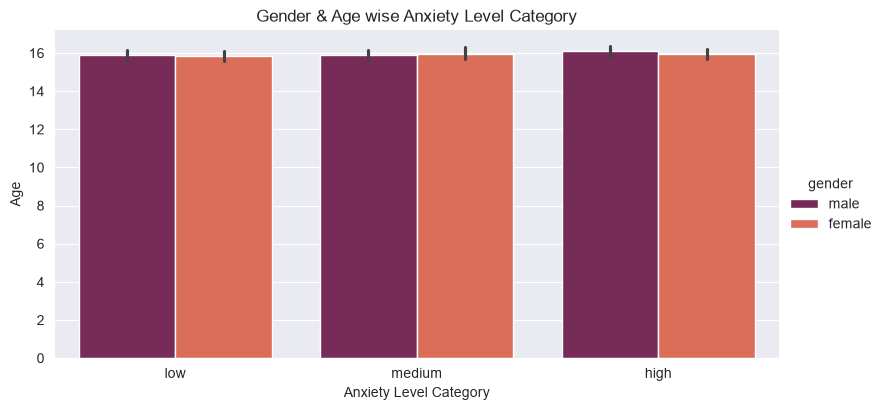

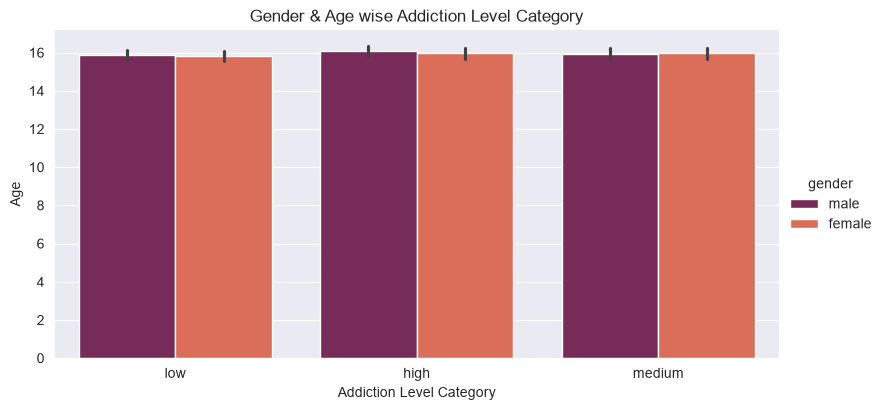

In [18]:
sns.catplot(data=df, y='age', x='sleep_quality', hue='gender', kind='bar', aspect=2, height=4, palette='rocket')
plt.xlabel('Sleep Quality')
plt.ylabel('Age')
plt.title('Gender & Age wise Sleep Quality distribution')

sns.catplot(data=df, y='age', x='social_interaction_level', hue='gender', kind='bar', aspect=2, height=4, palette='rocket')
plt.xlabel('Social Interaction Level')
plt.ylabel('Age')
plt.title('Gender & Age wise Social Interaction distribution')

sns.catplot(data=df, y='age', x='digital_wellbeing_flag', hue='gender', kind='bar', aspect=2, height=4, palette='rocket')
plt.xlabel('Digital Wellbeing Flag')
plt.ylabel('Age')
plt.title('Gender & Age wise Digital Wellbeing Flag')

sns.catplot(data=df, y='age', x='stress_level_category', hue='gender', kind='bar', aspect=2, height=4, palette='rocket')
plt.xlabel('Stress Level Category')
plt.ylabel('Age')
plt.title('Gender & Age wise Stress Level Category')

sns.catplot(data=df, y='age', x='anxiety_level_category', hue='gender', kind='bar', aspect=2, height=4, palette='rocket')
plt.xlabel('Anxiety Level Category')
plt.ylabel('Age')
plt.title('Gender & Age wise Anxiety Level Category')

sns.catplot(data=df, y='age', x='addiction_level_category', hue='gender', kind='bar', aspect=2, height=4, palette='rocket')
plt.xlabel('Addiction Level Category')
plt.ylabel('Age')
plt.title('Gender & Age wise Addiction Level Category')

plt.show()

As per the above charts, we can say that the following columns, `sleep_quality` `digital_wellbeing_flag` `sleep_quality` `stress_level_category` `anxiety_level_category` & `addiction_level_category` are equally distributed.

Between those columns, we can consider one of them to be target column.

### Platform usage vs Gender

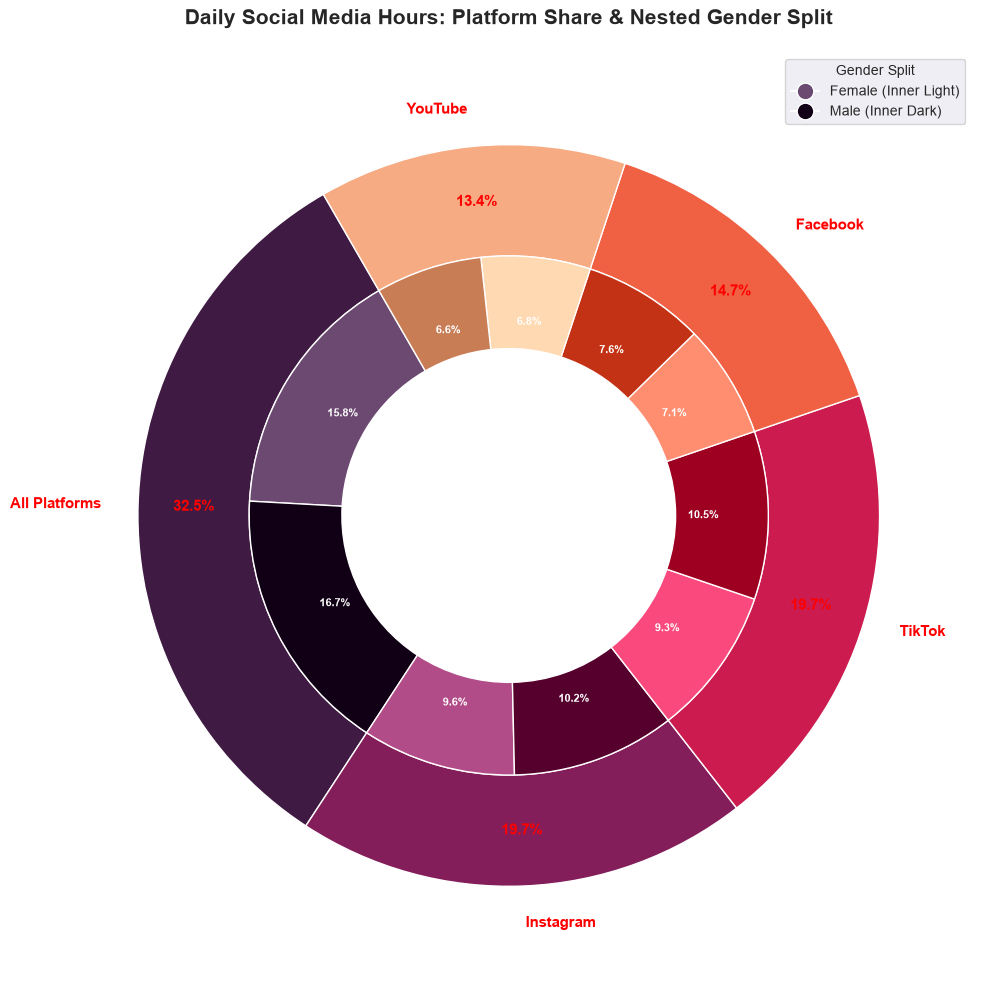

In [19]:
import matplotlib.colors as mcolors

platform_totals = df.groupby('platform_usage')['daily_social_media_hours'].sum().sort_values(ascending=False)
platforms = platform_totals.index

# 2. Get the gender breakdown sorted to match the outer platform order
gender_splits = []
for platform in platforms:
    f_val = df[(df['platform_usage'] == platform) & (df['gender'] == 'female')]['daily_social_media_hours'].sum()
    m_val = df[(df['platform_usage'] == platform) & (df['gender'] == 'male')]['daily_social_media_hours'].sum()
    gender_splits.extend([f_val, m_val])

# 3. Setup Colors
outer_colors = sns.color_palette("rocket", len(platforms))
inner_colors = []

# Generate matching inner shades (Lighter for Female, Darker for Male)
for col in outer_colors:
    rgb = mcolors.to_rgb(col)
    female_shade = [min(1.0, val + 0.18) for val in rgb]  # Softened color
    male_shade = [max(0.0, val - 0.18) for val in rgb]    # Deepened color
    inner_colors.extend([female_shade, male_shade])

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 10))

# Outer Ring: Platforms (Percentages placed closer to the outer edge at pctdistance=0.85)
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    platform_totals.values, 
    labels=platforms, 
    radius=1.0, 
    colors=outer_colors,
    autopct='%1.1f%%',
    pctdistance=0.85,
    textprops=dict(fontsize=11, fontweight='bold', color="red"),
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=120
)

# Inner Ring: Gender split (Percentages placed right in the middle of the inner ring at pctdistance=0.65)
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    gender_splits, 
    radius=0.7, 
    colors=inner_colors,
    autopct='%1.1f%%',                # Added autopct for the inner ring (whole numbers to save space)
    pctdistance=0.75,                 # Positioned the text in the middle of the inner ring
    textprops=dict(fontsize=8, color="white", fontweight="bold"), # Made the text smaller and white for contrast
    wedgeprops=dict(width=0.25, edgecolor='white'),
    startangle=120
)

# 5. Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Female (Inner Light)', 
               markerfacecolor=inner_colors[0], markersize=12),
    plt.Line2D([0], [0], marker='o', color='w', label='Male (Inner Dark)', 
               markerfacecolor=inner_colors[1], markersize=12)
]
ax.legend(handles=legend_elements, loc="upper right", title="Gender Split")

plt.title("Daily Social Media Hours: Platform Share & Nested Gender Split", fontsize=15, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

### Depression Status

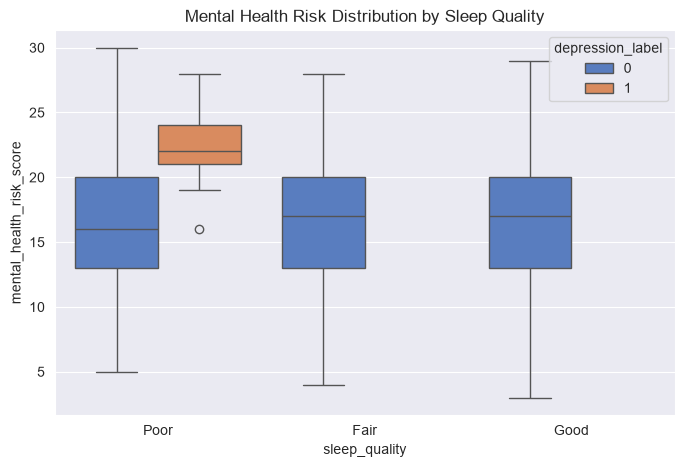

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x="sleep_quality", 
    y="mental_health_risk_score", 
    order=["Poor", "Fair", "Good"], 
    palette="muted",
    hue='depression_label'
)
plt.title("Mental Health Risk Distribution by Sleep Quality")
plt.show()

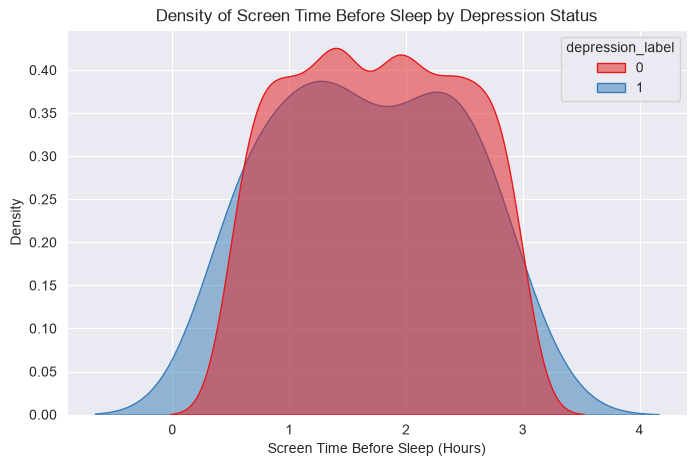

In [21]:
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df, 
    x="screen_time_before_sleep", 
    hue="depression_label", 
    fill=True, 
    common_norm=False, 
    palette="Set1", 
    alpha=0.5
)
plt.title("Density of Screen Time Before Sleep by Depression Status")
plt.xlabel("Screen Time Before Sleep (Hours)")
plt.show()

Above charts summarizes two points, 
    
- Poor `sleep_quality` tends to depression with higher mental risks.

- Depressed teens tend to have a higher density at lower screen time before sleep.

- Non-depressed teens are more concentrated at slightly higher screen time values.

However, these interpretation are as per the distribution, not proof that screen time causes depression.

### Academic Performance, Active Lifestyle & Social Dynamics

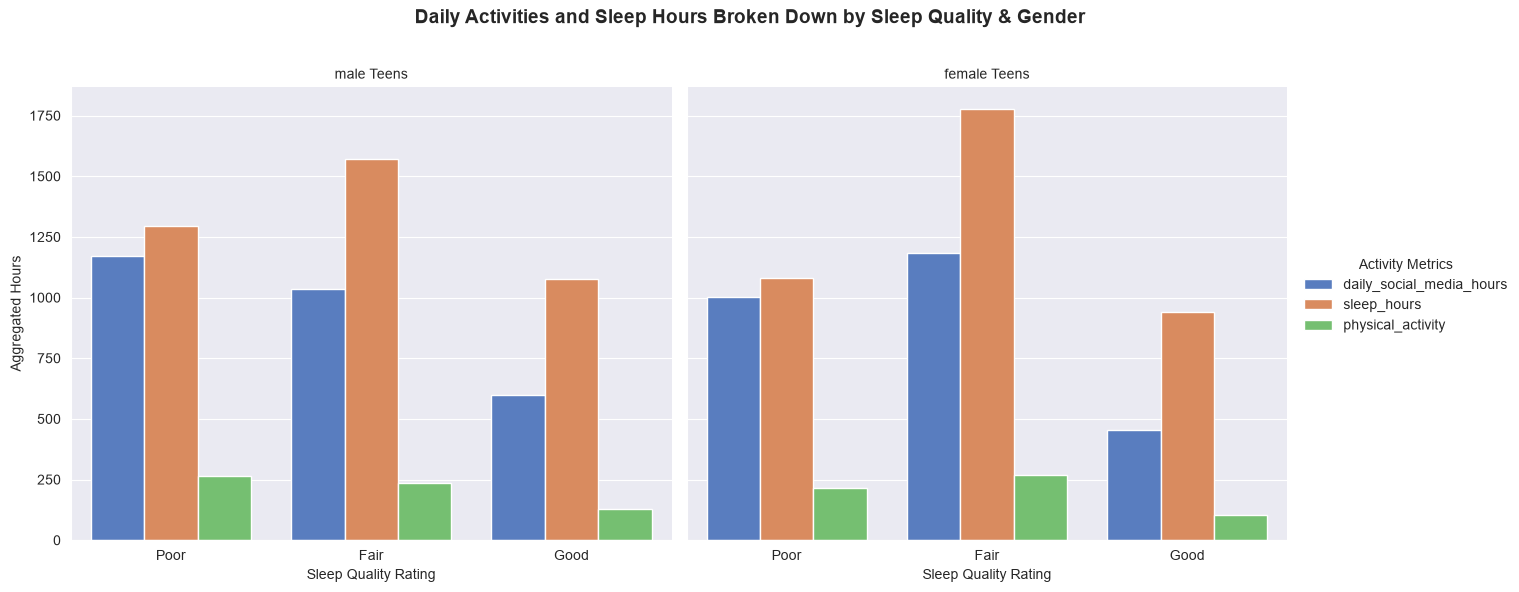

In [22]:
performance_data = df.groupby(['sleep_quality','gender'])[['daily_social_media_hours','sleep_hours','physical_activity']].sum().sort_values(ascending=False, by='gender')

plot_data = performance_data.reset_index()

# Melt the data to make it compatible with Seaborn's hue mapping
# This converts columns like 'sleep_hours' into rows under a single 'Metrics Activity' column
melted_data = pd.melt(
    plot_data, 
    id_vars=['sleep_quality', 'gender'], 
    value_vars=['daily_social_media_hours', 'sleep_hours', 'physical_activity'],
    var_name='Activity Metrics', 
    value_name='Total Hours'
)

# Create a FacetGrid of Bar Plots using sns.catplot
g = sns.catplot(
    data=melted_data,
    x='sleep_quality',
    y='Total Hours',
    hue='Activity Metrics',
    col='gender',          # Splits the plot into 2 columns: Male and Female
    kind='bar',
    palette='muted',
    height=6,
    aspect=1.1,
    order=['Poor', 'Fair', 'Good'] # Forces logical order for sleep quality
)

# Clean up titles and labels
g.set_titles("{col_name} Teens")
g.set_axis_labels("Sleep Quality Rating", "Aggregated Hours")

plt.subplots_adjust(top=0.85)
g.fig.suptitle("Daily Activities and Sleep Hours Broken Down by Sleep Quality & Gender", fontsize=14, fontweight='bold')

plt.show()

`Fair` sleepers dominate the dataset in total hours, not necessarily that they individually do more than `Good` sleepers. `Good` sleep quality is associated with lower total social media use and lower total physical activity here. The relationship is not a simple “more activity = better sleep”.

- Female teens in `Fair` sleep quality appear to have higher totals than Male teens in the same category.

## Feature Engineering

In [23]:
data.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833,16.647500
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704,5.038128
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000,13.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000,17.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000,20.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000,30.000000


In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_quality      

In [25]:
## Gather numerical and categorical feature

numerical_features = []
categorical_features = []

for col in data.columns:
    numerical_features.append(col) if data[col].dtypes in ['int64','float64'] else categorical_features.append(col)

numerical_features.remove('depression_label') # Remove depression_label, as it is a categorical feature

# nominal features
nominal_features = ['gender', 'platform_usage', 'digital_wellbeing_flag', 'depression_label']

# ordinal features
ordinal_features = ['social_interaction_level', 'sleep_quality']

print(f"Numerical Features: {numerical_features}\n")
print(f"Categorical Features: {categorical_features}\n")
print(f"Nominal Features: {nominal_features}\n")
print(f"Ordinal Features: {ordinal_features}")

Numerical Features: ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level', 'mental_health_risk_score']

Categorical Features: ['gender', 'platform_usage', 'social_interaction_level', 'sleep_quality', 'digital_wellbeing_flag']

Nominal Features: ['gender', 'platform_usage', 'digital_wellbeing_flag', 'depression_label']

Ordinal Features: ['social_interaction_level', 'sleep_quality']


#### Lets check for the Target Leakage

Why we check for Target Leakage before the regression modeling

**Target leakage** is checked before regression modeling to prevent **unrealistically high performance metrics** and ensure the model can **generalize** to unseen data.

*   **Consequence**: Models learn spurious correlations rather than causal relationships, leading to **overfitting** and a failure to perform in production.
*   **Detection**: It is identified by reviewing features for **temporal integrity** and ensuring no variables are direct copies or proxies of the target variable.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression, mutual_info_regression
from sklearn.preprocessing import OneHotEncoder

def split_data(features, target):

    X = data[features]
    y = data[target]
    
    return X, y

## Feature Selection function for Regression
def regression_FE(numeric_col, nominal_col=nominal_features, ordinal_col=ordinal_features, target_col=None):

    # split the data
    X, y = split_data(features=numeric_col, target=target_col)

    # mapping ordinal columns
    if ordinal_col:
        X['social_interaction_level'] = data['social_interaction_level'].map({'low':0, 'medium':1, 'high':2})
        X['sleep_quality'] = data['sleep_quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2})

    # preprocessssing gender column
    encoder = OneHotEncoder(sparse_output=False, dtype='int64',drop='first')
    encoded_res = encoder.fit_transform(data[nominal_col])

    encoded_raw = pd.DataFrame(
        encoded_res,
        columns=encoder.get_feature_names_out(nominal_col)
    )

    # concat the OHE result to X
    X = pd.concat(
        [X, encoded_raw],
        axis=1
    )

    all_features = X.columns.to_list()

    # scaling all features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # f_regression returns two arrays: F-statistic values and p-values
    f_stat, p_values = f_regression(X_scaled, y)

    # mutual_info_regression returns estimated mutual information scores (in nats)
    mi_scores = mutual_info_regression(X_scaled, y, random_state=42)

    # compile the results
    selection_summary = pd.DataFrame({
        'Feature': all_features,
        'F-Statistic': f_stat,
        'p-value': p_values,
        'Mutual Info Score': mi_scores
    })

    # Format p-values for clear readability (scientific notation for small values)
    selection_summary['p-value'] = selection_summary['p-value'].apply(lambda x: f"{x:.4e}" if x < 0.0001 else f"{x:.4f}")

    # Sort by Mutual Information Score to bubble up the most relevant variables instantly
    selection_summary = selection_summary.sort_values(by='Mutual Info Score', ascending=False).reset_index(drop=True)

    print("\n\n--- Feature Selection Metrics Summary ---\n")
    print(selection_summary)

In [27]:
print("Running regression_FE for all the features:\n\n")

regression_FE(numeric_col=numerical_features[:-1], target_col='mental_health_risk_score')

Running regression_FE for all the features:




--- Feature Selection Metrics Summary ---

                            Feature  F-Statistic      p-value  \
0                   addiction_level   605.565969  1.4840e-108   
1                      stress_level   623.825526  3.5215e-111   
2                     anxiety_level   653.757098  1.9992e-115   
3                depression_label_1    43.237091   7.2236e-11   
4          social_interaction_level     1.720751       0.1898   
5          platform_usage_Instagram     0.056498       0.8122   
6                     sleep_quality     1.126236       0.2888   
7            platform_usage_YouTube     0.599391       0.4390   
8   digital_wellbeing_flag_Moderate     0.002330       0.9615   
9          screen_time_before_sleep     0.034588       0.8525   
10                              age     0.409161       0.5225   
11                      sleep_hours     2.311038       0.1287   
12         daily_social_media_hours     0.453943       0.5006   

#### The Regression Target (`mental_health_risk_score`)

As per the `F-Regression` `p-value` and `Mutual Info` summary, three features completely dominate:

1. **`anxiety_level`**
2. **`stress_level`**
3. **`addiction_level`**

Due to the massive F-statistics (above 600) and high Mutual Information scores (~0.23). Every other feature drops sharply down to near-zero importance.

**🚨 The Target Leakage Issue**

While we look closely at **feature #13**: `depression_label_1` has a high F-statistic ($43.2$) against the risk score. This proves that `mental_health_risk_score` is a highly derived index column computed directly from a patient's individual anxiety, stress, addiction, and depression metrics.

**My goal is to create predictive modeling** so, dropping `anxiety_level`, `stress_level`, and `addiction_level` to force the model to look at the **underlying behaviors** (sleep, screen time, social habits).

However, we will move one step forward to calculate VIF before dropping any columns.

---

#### Checking Multi-Colinearity (VIF-Variance Inflation Factor)

Univariate tests tell us, if a feature relates to the target, but they say **nothing about whether features relate to *each other***. Look at the four strong features: `addiction_level`, `anxiety_level`, `stress_level`, `depression_label`. These are conceptually overlapping psychological constructs — someone with high anxiety often also scores high on stress and addiction measures. They're very likely **collinear**.

This matters because:
- If we build a **linear regression**, multicollinearity inflates coefficient variance — coefficients become unstable and hard to interpret (a feature's coefficient sign can even flip with small data changes)
- It doesn't hurt *prediction accuracy* much, but it destroys **interpretability** ("how much does anxiety alone drive risk score?" becomes unanswerable)
- Tree-based models (Random Forest, XGBoost) are largely immune to this — so VIF matters more if you're going the linear regression route

In [28]:
from sklearn.linear_model import RidgeCV, LassoCV, LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
    
def check_vif(features, target_feature=None):

    missing = set(features) - set(data.columns)
    if missing:
        print('Missing features from dataset:', missing)
        raise SystemExit(1)

    X, y = split_data(features=features, target=target_feature)

    # ordinal encode
    if 'sleep_quality' in features:
        X['sleep_quality'] = data['sleep_quality'].map({'Poor':0,'Fair':1,'Good':2})
    
    if 'social_interaction_level' in features:
        X['social_interaction_level'] = data['social_interaction_level'].map({'low':0,'medium':1,'high':2})

    # nominal encode
    nominal_col = [col for col in nominal_features if col in features]
    if nominal_col:
        encoder = OneHotEncoder(sparse_output=False, dtype='int64',drop='first')
        encoded_res = encoder.fit_transform(data[nominal_col])

        encoded_raw = pd.DataFrame(
            encoded_res,
            columns=encoder.get_feature_names_out(nominal_col)
        )

        # concat the OHE result to X
        X = pd.concat(
            [X, encoded_raw],
            axis=1
        )

    # prepare numeric subset for VIF
    X_vif = X.select_dtypes(include=[np.number]).copy()

    # compute VIF
    try:
        from statsmodels.stats.outliers_influence import variance_inflation_factor
        def compute_vif(df_):
            X_mat = df_.values
            vifs = [variance_inflation_factor(X_mat, i) for i in range(X_mat.shape[1])]
            return pd.DataFrame({'feature':df_.columns,'VIF':vifs})
        vif_df = compute_vif(X_vif)
    except Exception:
        # fallback
        def compute_vif_fallback(df_):
            vifs=[]
            for col in df_.columns:
                X_ = df_.drop(columns=[col])
                y_ = df_[col]
                model = LinearRegression()
                model.fit(X_, y_)
                r2 = model.score(X_, y_)
                vifs.append(1.0/(1.0-r2) if r2 < 0.999 else np.inf)
            return pd.DataFrame({'feature':df_.columns,'VIF':vifs})
        vif_df = compute_vif_fallback(X_vif)
    print("--- VIF Results ---")
    print("""
    Interpretation:
    VIF = 1        -> no correlation with other features
    VIF 1-5        -> moderate, generally acceptable
    VIF 5-10       -> high correlation, investigate
    VIF > 10       -> severe multicollinearity, consider dropping/combining
    """)
    print('*'*50)
    print('\nInitial VIF:')
    print(vif_df.to_string(index=False))
    print('*'*50)

    # iterative drop >5
    X_iter = X_vif.copy()
    dropped = []
    while True:
        try:
            try:
                vif_curr = compute_vif(X_iter)
            except NameError:
                vif_curr = compute_vif_fallback(X_iter)
        except Exception as e:
            print('Error computing VIF:', e)
            break
        high = vif_curr[vif_curr['VIF']>5]
        if high.empty:
            break
        drop_feat = high.sort_values('VIF',ascending=False).iloc[0]['feature']
        dropped.append(drop_feat)
        X_iter = X_iter.drop(columns=[drop_feat])

    print('\nDropped features due to high VIF:', dropped)
    print('*'*50)
    print('\nFinal VIF:')
    print(vif_curr.to_string(index=False))

    for item in dropped:
        features.remove(item)
    
    return features

In [29]:
# selected features according to F-Statistics & Mutual Info Score
selected_features = ['addiction_level',
 'stress_level',
 'anxiety_level',
 'sleep_hours',
 'daily_social_media_hours',
 'sleep_quality']

## Running the Function for VIF result
selected_features = check_vif(features=selected_features, target_feature='mental_health_risk_score')

--- VIF Results ---

    Interpretation:
    VIF = 1        -> no correlation with other features
    VIF 1-5        -> moderate, generally acceptable
    VIF 5-10       -> high correlation, investigate
    VIF > 10       -> severe multicollinearity, consider dropping/combining
    
**************************************************

Initial VIF:
                 feature       VIF
         addiction_level  4.608174
            stress_level  4.435795
           anxiety_level  4.691112
             sleep_hours 25.679467
daily_social_media_hours  5.782389
           sleep_quality  5.527102
**************************************************

Dropped features due to high VIF: ['sleep_hours']
**************************************************

Final VIF:
                 feature      VIF
         addiction_level 3.799953
            stress_level 3.713643
           anxiety_level 4.010740
daily_social_media_hours 4.415773
           sleep_quality 1.974839


#### Forward/Backward Selection

You've essentially already done the job of a **filter method** — 10 of your 14+ features are dead weight (MI ≈ 0, p > 0.05). You don't need sequential selection to tell you to drop `age` or `physical_activity`; the data already told you.

Where forward/backward selection *still* adds value: among the **remaining strong candidates**, since they're likely collinear, adding all four might not actually improve cross-validated performance over just two or three of them. Sequential selection (evaluated via actual model performance, not just p-values) will catch that redundancy — filter methods can't, because they never look at features in combination.

In [30]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split, cross_val_score

# ==================================================================
# Forward & Backward Selection (confirms redundancy via CV performance)
# ==================================================================

def forward_backward_selection(features, target):

    X, y = split_data(features=features, target=target)

    # ordinal encode
    if 'sleep_quality' in features:
        X['sleep_quality'] = data['sleep_quality'].map({'Poor':0,'Fair':1,'Good':2})
    
    if 'social_interaction_level' in features:
        X['social_interaction_level'] = data['social_interaction_level'].map({'low':0,'medium':1,'high':2})

    # nominal encode
    nominal_col = [col for col in nominal_features if col in features]
    if nominal_col:
        encoder = OneHotEncoder(sparse_output=False, dtype='int64',drop='first')
        encoded_res = encoder.fit_transform(data[nominal_col])

        encoded_raw = pd.DataFrame(
            encoded_res,
            columns=encoder.get_feature_names_out(nominal_col)
        )

        # concat the OHE result to X
        X = pd.concat(
            [X, encoded_raw],
            axis=1
        )
    X = X.drop(nominal_col, axis=1)

    all_features = X.columns.to_list()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Ridge/Lasso are sensitive to feature scale (unlike plain OLS) — always scale
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test), columns=X_test.columns, index=X_test.index
    )
    
    SCORING = "neg_mean_squared_error"   
    
    # Candidate alpha ranges — RidgeCV/LassoCV pick the best one internally via CV
    alphas = np.logspace(-3, 3, 50)   # 0.001 to 1000, log-spaced
    
    models = {
        "LinearRegression": LinearRegression(),
        "RidgeCV": RidgeCV(alphas=alphas, scoring=SCORING, cv=5),
        "LassoCV": LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42),
    }
    
    results = {}
    
    for model_name, model in models.items():
        print(f"\n{'='*60}\n{model_name}\n{'='*60}")
    
        # Baseline: performance using ALL shortlisted features
        baseline_scores = cross_val_score(
            model, X_train_scaled, y_train, cv=5, scoring=SCORING
        )
        baseline_rmse = np.sqrt(-baseline_scores.mean())
        print(f"Baseline CV RMSE (all {len(features)} features): "
            f"{baseline_rmse:.4f}")
    
        # Forward selection
        forward_selector = SequentialFeatureSelector(
            model, n_features_to_select="auto", direction="forward",
            scoring=SCORING, cv=5
        )
        forward_selector.fit(X_train_scaled, y_train)
        forward_features = X_train_scaled.columns[forward_selector.get_support()].tolist()
    
        # Backward selection
        backward_selector = SequentialFeatureSelector(
            model, n_features_to_select="auto", direction="backward",
            scoring=SCORING, cv=5
        )
        backward_selector.fit(X_train_scaled, y_train)
        backward_features = X_train_scaled.columns[backward_selector.get_support()].tolist()
    
        print(f"[Forward]  Selected: {forward_features}")
        print(f"[Backward] Selected: {backward_features}")
    
        # RMSE using forward-selected feature subset, evaluated on held-out test set
        model.fit(X_train_scaled[forward_features], y_train)
        test_preds = model.predict(X_test_scaled[forward_features])
        test_rmse = np.sqrt(np.mean((y_test - test_preds) ** 2))
        print(f"Test RMSE using forward-selected features: {test_rmse:.4f}")
    
        # RidgeCV / LassoCV pick their own alpha internally — report what was chosen
        if model_name in ("RidgeCV", "LassoCV"):
            model.fit(X_train_scaled, y_train)
            print(f"Selected alpha_: {model.alpha_:.4f}")
    
        # For LassoCV specifically: check which coefficients got shrunk to zero
        if model_name == "LassoCV":
            coef_summary = pd.Series(model.coef_, index=X_train_scaled.columns)
            print("\nLassoCV coefficients (0 = feature effectively dropped):")
            print(coef_summary.sort_values(key=abs, ascending=False))
    
        results[model_name] = {
            "baseline_rmse": baseline_rmse,
            "forward_features": forward_features,
            "backward_features": backward_features,
            "test_rmse": test_rmse,
        }
    
    # ==================================================================
    # Cross-model comparison
    # ==================================================================
    print(f"\n{'='*60}\nSummary Across Models\n{'='*60}")
    summary_df = pd.DataFrame(results).T
    print(summary_df[["baseline_rmse", "test_rmse"]])
    
    print("""
    Decision guide:
    - If Forward == Backward == all shortlisted features across every model:
    no redundancy — features are each contributing distinct signal.
    - If Lasso zeroes out a coefficient AND forward/backward selection also
    drops it: strong, convergent evidence that feature is redundant.
    - If plain LinearRegression's selection is unstable (forward != backward)
    but Ridge's is consistent: confirms multicollinearity is the cause —
    Ridge handles it better than unregularized Linear Regression.
    - Compare test_rmse across models: Ridge/Lasso winning by a meaningful
    margin over plain LinearRegression further confirms collinearity was
    hurting the unregularized model.
    """)

    return X_train, X_test, y_train, y_test

In [31]:
X_train, X_test, y_train, y_test = forward_backward_selection(features=selected_features, target='mental_health_risk_score')


LinearRegression
Baseline CV RMSE (all 5 features): 0.0000
[Forward]  Selected: ['stress_level', 'anxiety_level']
[Backward] Selected: ['addiction_level', 'stress_level', 'anxiety_level']
Test RMSE using forward-selected features: 2.7627

RidgeCV
Baseline CV RMSE (all 5 features): 0.0000
[Forward]  Selected: ['stress_level', 'anxiety_level']
[Backward] Selected: ['addiction_level', 'stress_level', 'anxiety_level']
Test RMSE using forward-selected features: 2.7627
Selected alpha_: 0.0010

LassoCV
Baseline CV RMSE (all 5 features): 0.0615
[Forward]  Selected: ['stress_level', 'anxiety_level']
[Backward] Selected: ['addiction_level', 'stress_level', 'anxiety_level']
Test RMSE using forward-selected features: 2.7627
Selected alpha_: 0.0391

LassoCV coefficients (0 = feature effectively dropped):
stress_level                2.891246
anxiety_level               2.810832
addiction_level             2.806599
daily_social_media_hours    0.000000
sleep_quality              -0.000000
dtype: floa

### Model Family Comparison + Hyperparameter Tuning + Residual Diagnostics

**What it does:**
  1. Compares Linear family (RidgeCV/LassoCV) vs Tree/Boosting family
     (Random Forest, XGBoost) using consistent cross-validation
  2. Hyperparameter-tunes the tree/boosting models with RandomizedSearchCV
  3. Runs residual diagnostics if a linear model is competitive
  4. Reports final metrics on a held-out test set
  5. Saves the winning pipeline (scaler + model) to disk

In [32]:
from scipy import stats
from scipy.stats import randint, uniform
 
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
 
# ==================================================================
# Compare model families with consistent CV
# ==================================================================

def build_tune_model(X_train, X_test, y_train, y_test):

    alphas = np.logspace(-3, 3, 50)
    
    candidates = {
        "RidgeCV": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(alphas=alphas, cv=5))
        ]),
        "LassoCV": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(alphas=alphas, cv=5, max_iter=10000, random_state=42))
        ]),
        "RandomForest": Pipeline([
            ("model", RandomForestRegressor(n_estimators=200, random_state=42))
        ]),  # tree-based models don't need scaling
        "XGBoost": Pipeline([
            ("model", XGBRegressor(n_estimators=200, random_state=42, verbosity=0))
        ]),
    }
    
    print("--- Cross-Validated RMSE by Model Family ---")
    cv_results = {}
    for name, pipe in candidates.items():
        scores = cross_val_score(
            pipe, X_train, y_train, cv=5, scoring="neg_mean_squared_error"
        )
        rmse = np.sqrt(-scores.mean())
        cv_results[name] = rmse
        print(f"{name:15s} CV RMSE: {rmse:.4f}")
    
    best_family = min(cv_results, key=cv_results.get)
    print(f"\nBest performing family (pre-tuning): {best_family}")
    
    # ==================================================================
    # Hyperparameter tune the tree/boosting models
    # (Linear models already tuned via RidgeCV/LassoCV's internal alpha search)
    # ==================================================================
    print("\n--- Hyperparameter Tuning: Random Forest ---")
    rf_param_dist = {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(3, 20),
        "model__min_samples_split": randint(2, 10),
        "model__min_samples_leaf": randint(1, 5),
        "model__max_features": uniform(0.3, 0.7),
    }
    rf_search = RandomizedSearchCV(
        candidates["RandomForest"], rf_param_dist, n_iter=30, cv=5,
        scoring="neg_mean_squared_error", random_state=42, n_jobs=-1
    )
    rf_search.fit(X_train, y_train)
    print("Best RF params:", rf_search.best_params_)
    print("Best RF CV RMSE:", np.sqrt(-rf_search.best_score_))
    
    print("\n--- Hyperparameter Tuning: XGBoost ---")
    xgb_param_dist = {
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(2, 10),
        "model__learning_rate": uniform(0.01, 0.29),
        "model__subsample": uniform(0.6, 0.4),
        "model__colsample_bytree": uniform(0.6, 0.4),
    }
    xgb_search = RandomizedSearchCV(
        candidates["XGBoost"], xgb_param_dist, n_iter=30, cv=5,
        scoring="neg_mean_squared_error", random_state=42, n_jobs=-1
    )
    xgb_search.fit(X_train, y_train)
    print("Best XGB params:", xgb_search.best_params_)
    print("Best XGB CV RMSE:", np.sqrt(-xgb_search.best_score_))
    
    # ==================================================================
    # Final comparison — pick the actual winner
    # ==================================================================
    final_candidates = {
        "RidgeCV": candidates["RidgeCV"],
        "LassoCV": candidates["LassoCV"],
        "RandomForest (tuned)": rf_search.best_estimator_,
        "XGBoost (tuned)": xgb_search.best_estimator_,
    }
    
    print("\n--- Final Test Set Performance ---")
    final_results = {}
    for name, pipe in final_candidates.items():
        pipe.fit(X_train, y_train)
        preds = pipe.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        final_results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
        print(f"{name:22s} RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")
    
    winner_name = min(final_results, key=lambda k: final_results[k]["RMSE"])
    winner_pipe = final_candidates[winner_name]
    print(f"\nWinner: {winner_name}")
    
    # ==================================================================
    # Residual diagnostics (only meaningful if a linear model wins)
    # ==================================================================
    if winner_name in ("RidgeCV", "LassoCV"):
        print("\n--- Residual Diagnostics (Linear Model Assumptions) ---")
        preds = winner_pipe.predict(X_test)
        residuals = y_test - preds
    
        # 1. Normality of residuals (Shapiro-Wilk test)
        stat, p_normal = stats.shapiro(residuals)
        print(f"Shapiro-Wilk normality test: stat={stat:.4f}, p={p_normal:.4f}")
        print("  -> Residuals look normal" if p_normal > 0.05
            else "  -> Residuals deviate from normality (p < 0.05)")
    
        # 2. Homoscedasticity check (correlation between |residuals| and predictions)
        het_corr = np.corrcoef(np.abs(residuals), preds)[0, 1]
        print(f"Correlation(|residuals|, predictions): {het_corr:.4f}")
        print("  -> Roughly constant variance" if abs(het_corr) < 0.2
            else "  -> Possible heteroscedasticity (variance changes with prediction level)")
    
        # 3. Mean residual should be ~0
        print(f"Mean residual: {residuals.mean():.4f} (should be close to 0)")
    else:
        print(f"\n{winner_name} won — residual diagnostics not applicable "
            "(tree/boosting models don't assume linearity or homoscedasticity).")

## Building and Tuning the model       
build_tune_model(X_train, X_test, y_train, y_test)

--- Cross-Validated RMSE by Model Family ---
RidgeCV         CV RMSE: 0.0000
LassoCV         CV RMSE: 0.0615
RandomForest    CV RMSE: 0.6067
XGBoost         CV RMSE: 0.4290

Best performing family (pre-tuning): RidgeCV

--- Hyperparameter Tuning: Random Forest ---
Best RF params: {'model__max_depth': 10, 'model__max_features': np.float64(0.8911736940747059), 'model__min_samples_leaf': 1, 'model__min_samples_split': 3, 'model__n_estimators': 466}
Best RF CV RMSE: 0.6135315699203069

--- Hyperparameter Tuning: XGBoost ---
Best XGB params: {'model__colsample_bytree': np.float64(0.602208846849441), 'model__learning_rate': np.float64(0.2464838142519019), 'model__max_depth': 2, 'model__n_estimators': 491, 'model__subsample': np.float64(0.8916028672163949)}
Best XGB CV RMSE: 0.18445804703691823

--- Final Test Set Performance ---
RidgeCV                RMSE=0.0000  MAE=0.0000  R2=1.0000
LassoCV                RMSE=0.0687  MAE=0.0573  R2=0.9998
RandomForest (tuned)   RMSE=0.5308  MAE=0.4093  R

**Heads up: We’ve got a data leakage problem.**

I ran the numbers, and RidgeCV hit an R² of 1.0 and an RMSE of 0.0. In a vacuum, that looks amazing, but in ML, that’s a huge red flag. No real-world data is this "clean."

**Here is the key-points:**
Ridge nailed it perfectly, but our tree-based models (RF and XGBoost) actually struggled. This is a classic sign that the target is just a linear combination of the features. Trees can't do "straight lines" very well, but Ridge loves them. It’s almost certain that the `mental_health_risk_score` was created by just adding up a few of these columns.

**The fix:**
We can't use features like `stress_level` or `anxiety_level` to predict a risk score that is *made* of stress and anxiety—that's cheating (even if it's unintentional!).

I’m going to strip out the leakage group and rerun everything using only the behavioral data (sleep, screen time, etc.). The performance will definitely drop, but it'll be an honest result that we can actually trust.

In [33]:
## Separating the features

leakage_features = ['stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
behavioral_features = [
    'age', 'gender', 'daily_social_media_hours', 'platform_usage',
    'sleep_hours', 'sleep_quality', 'screen_time_before_sleep',
    'academic_performance', 'physical_activity', 'social_interaction_level'
]

print("-- Evaluating VIF --")
selected_features = check_vif(features=behavioral_features, target_feature=numerical_features[-1])

-- Evaluating VIF --
--- VIF Results ---

    Interpretation:
    VIF = 1        -> no correlation with other features
    VIF 1-5        -> moderate, generally acceptable
    VIF 5-10       -> high correlation, investigate
    VIF > 10       -> severe multicollinearity, consider dropping/combining
    
**************************************************

Initial VIF:
                 feature       VIF
                     age 42.992641
daily_social_media_hours  5.903862
             sleep_hours 85.679906
           sleep_quality 10.239669
screen_time_before_sleep  6.834088
    academic_performance 24.722741
       physical_activity  4.037986
social_interaction_level  2.422724
             gender_male  2.045269
 platform_usage_Facebook  1.437371
platform_usage_Instagram  1.607732
   platform_usage_TikTok  1.607384
  platform_usage_YouTube  1.407657
**************************************************

Dropped features due to high VIF: ['sleep_hours', 'age', 'academic_performance']
*******

In [34]:
# Cross validation with Forward Backward Selection
X_train, X_test, y_train, y_test = forward_backward_selection(features=selected_features, target='mental_health_risk_score')


LinearRegression
Baseline CV RMSE (all 7 features): 5.0681
[Forward]  Selected: ['daily_social_media_hours', 'physical_activity', 'social_interaction_level', 'gender_male', 'platform_usage_Instagram']
[Backward] Selected: ['daily_social_media_hours', 'social_interaction_level', 'gender_male', 'platform_usage_Instagram', 'platform_usage_TikTok']
Test RMSE using forward-selected features: 5.1343

RidgeCV
Baseline CV RMSE (all 7 features): 5.0381
[Forward]  Selected: ['daily_social_media_hours', 'physical_activity', 'social_interaction_level', 'gender_male', 'platform_usage_Instagram']
[Backward] Selected: ['daily_social_media_hours', 'physical_activity', 'social_interaction_level', 'gender_male', 'platform_usage_Instagram']
Test RMSE using forward-selected features: 5.1265
Selected alpha_: 1000.0000

LassoCV
Baseline CV RMSE (all 7 features): 5.0242
[Forward]  Selected: ['daily_social_media_hours', 'sleep_quality', 'screen_time_before_sleep', 'gender_male', 'platform_usage_Facebook']
[B

In [35]:
# Building & Tuning Hyper-parameter for XGBoost/RandomForest
build_tune_model(X_train, X_test, y_train, y_test)

--- Cross-Validated RMSE by Model Family ---
RidgeCV         CV RMSE: 5.0382
LassoCV         CV RMSE: 5.0244
RandomForest    CV RMSE: 5.3429
XGBoost         CV RMSE: 6.0750

Best performing family (pre-tuning): LassoCV

--- Hyperparameter Tuning: Random Forest ---
Best RF params: {'model__max_depth': 3, 'model__max_features': np.float64(0.5129695700716763), 'model__min_samples_leaf': 2, 'model__min_samples_split': 6, 'model__n_estimators': 335}
Best RF CV RMSE: 5.0464595867717685

--- Hyperparameter Tuning: XGBoost ---
Best XGB params: {'model__colsample_bytree': np.float64(0.8446612641953124), 'model__learning_rate': np.float64(0.012049228513718048), 'model__max_depth': 2, 'model__n_estimators': 148, 'model__subsample': np.float64(0.8099098641033556)}
Best XGB CV RMSE: 5.051897413890027

--- Final Test Set Performance ---
RidgeCV                RMSE=5.1245  MAE=4.2795  R2=-0.0111
LassoCV                RMSE=5.1220  MAE=4.2736  R2=-0.0102
RandomForest (tuned)   RMSE=5.1695  MAE=4.3140 

Depending on who you are presenting this to, you will want a different "flavor." Since a negative $R^2$ is usually scary to people who aren't data scientists, the goal here is to pivot the conversation from **"the model failed"** to **"the data gave us an answer."**

**The Results: An Honest Look at Predictive Power**

While the results may look discouraging at first glance, they actually provide us with a very clear and honest answer.

**Understanding the Negative $R^2$**
You’ll notice that the $R^2$ values for all four models (Ridge, Lasso, Random Forest, and XGBoost) are slightly negative (between -0.01 and -0.03). In plain English, this means the models are performing slightly worse than if we had simply guessed the average risk score for every person. This isn't a failure of the algorithms; rather, the models are telling us that there is no usable signal in the behavioral data—such as sleep hours, social media use, or academic performance—that can reliably predict the risk score.

**Connecting the Dots**
This is the exact opposite of our previous run. Last time, the "leakage" features gave us a suspiciously perfect fit. Now, by using only legitimate behavioral features, we see a near-zero fit. This confirms a critical point: the risk score is driven almost entirely by psychological subscales (stress, anxiety, etc.), and the behavioral proxies we have don't provide enough information to reconstruct that score.

**The Bottom Line**
To the research question—*"Can mental health risk be predicted from digital behavior and lifestyle factors?"*—the evidence in this dataset says **no**. 

This is actually a defensible finding. In real-world adolescent research, behavioral habits (like screen time) rarely explain mental health risk as strongly as internal psychological states. Whether this is a reflection of real-world complexity or a result of how this synthetic data was generated, we have now ruled out both linear and non-linear relationships.

**Conclusion:**
```bash
Does digital behavior predict mental health risk in this dataset? **Nope.** 

This is actually a pretty interesting finding. It shows that behavior $\neq$ psychological state. Either that's a real-world truth we've captured, or whoever made this synthetic dataset didn't actually build a link between behavior and the final score. Either way, we've officially ruled out the "easy" answers!
```

## Regression with PyTorch — Feedforward Neural Network

In [36]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

torch.manual_seed(42)
np.random.seed(42)

In [37]:
# ------------------------------------------------------------------
# 0. Load data — use the non-leaky behavioral feature set
# ------------------------------------------------------------------
 
behavioral_features = [
    'age', 'daily_social_media_hours', 'sleep_hours', 'sleep_quality',
    'screen_time_before_sleep', 'academic_performance',
    'physical_activity', 'social_interaction_level'
]
target_column = 'mental_health_risk_score'
 
X = data[behavioral_features].copy()
y = data[target_column].values.astype(np.float32)

In [38]:
# Encode ordinal/categorical columns if present
# (checks non-numeric dtype robustly, since pandas may report 'object' or 'str')
if 'sleep_quality' in X.columns and not pd.api.types.is_numeric_dtype(X['sleep_quality']):
    X['sleep_quality'] = X['sleep_quality'].map({'Poor': 0, 'Fair': 1, 'Good': 2})
if 'social_interaction_level' in X.columns and not pd.api.types.is_numeric_dtype(X['social_interaction_level']):
    X['social_interaction_level'] = X['social_interaction_level'].map(
        {'low': 0, 'medium': 1, 'high': 2}
    )
 
X = X.values.astype(np.float32)
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
# Neural nets need scaled inputs to train well (gradient descent is
# sensitive to feature scale, unlike tree-based splits)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
 
# Also scale the target — keeps loss values in a sane range and
# helps gradient descent converge; we inverse-transform for reporting
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()
 
# Further split train into train/val for early stopping
X_train, X_val, y_train_scaled, y_val_scaled = train_test_split(
    X_train, y_train_scaled, test_size=0.15, random_state=42
)

In [40]:
# ------------------------------------------------------------------
# 1. Dataset / DataLoader
# ------------------------------------------------------------------
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
 
    def __len__(self):
        return len(self.X)
 
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
 
 
train_loader = DataLoader(TabularDataset(X_train, y_train_scaled), batch_size=32, shuffle=True)
val_loader = DataLoader(TabularDataset(X_val, y_val_scaled), batch_size=64, shuffle=False)

In [41]:
# ------------------------------------------------------------------
# 2. Model definition — small MLP, appropriate for a handful of features
# ------------------------------------------------------------------
class RegressionMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=(32, 16), dropout=0.1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
 
    def forward(self, x):
        return self.net(x)
 
 
model = RegressionMLP(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [44]:
# ------------------------------------------------------------------
# 3. Training loop with early stopping
# ------------------------------------------------------------------
n_epochs = 200
patience = 15
best_val_loss = float('inf')
epochs_no_improve = 0
best_state = None
 
for epoch in range(1, n_epochs + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)
 
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            val_loss += criterion(preds, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
 
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
 
    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")
 
    # if epochs_no_improve >= patience:
    #     print(f"Early stopping at epoch {epoch} (no val improvement for {patience} epochs)")
    #     break
 
model.load_state_dict(best_state)  # restore best-val-loss weights

Epoch   1 | train_loss=0.9997 | val_loss=1.0309
Epoch  20 | train_loss=0.9423 | val_loss=1.0705
Epoch  40 | train_loss=0.9115 | val_loss=1.0948
Epoch  60 | train_loss=0.8992 | val_loss=1.1138
Epoch  80 | train_loss=0.8401 | val_loss=1.1368
Epoch 100 | train_loss=0.8594 | val_loss=1.1275
Epoch 120 | train_loss=0.8333 | val_loss=1.1423
Epoch 140 | train_loss=0.8198 | val_loss=1.1622
Epoch 160 | train_loss=0.7790 | val_loss=1.1812
Epoch 180 | train_loss=0.7909 | val_loss=1.1802
Epoch 200 | train_loss=0.7687 | val_loss=1.2002


<All keys matched successfully>

In [45]:
# ------------------------------------------------------------------
# 4. Final evaluation on the held-out test set (original scale)
# ------------------------------------------------------------------
model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    preds_scaled = model(X_test_t).numpy().flatten()
 
preds = y_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
 
rmse = np.sqrt(mean_squared_error(y_test, preds))
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)
 
print("\n--- PyTorch MLP: Final Test Set Performance ---")
print(f"RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")


--- PyTorch MLP: Final Test Set Performance ---
RMSE=5.1633  MAE=4.2990  R2=-0.0265
